In [1]:
import pandas as pd

df = pd.read_csv("mp_data.csv")

df.head()

,name,attendance,debates,questions
0,Gaurav Gogoi,85,29,117
1,Jai Parkash,97,5,43
2,Sarbananda Sonowal,0,0,0
3,Bibhu Prasad Tarai,93,14,141
4,Shobhanaben Mahendrasinh Baraiya,98,15,173


In [2]:
df["attendance"] = pd.to_numeric(df["attendance"], errors="coerce")
df["debates"] = pd.to_numeric(df["debates"], errors="coerce")
df["questions"] = pd.to_numeric(df["questions"], errors="coerce")

df.fillna(0, inplace=True)

df.describe()

,attendance,debates,questions
count,10.000000,10.000000,10.000000
mean,73.000000,14.500000,95.500000
std,39.018514,14.001984,69.679026
min,0.000000,0.000000,0.000000
25%,79.750000,2.000000,45.750000
50%,89.500000,13.500000,108.000000
75%,96.750000,24.000000,137.000000
max,98.000000,41.000000,203.000000


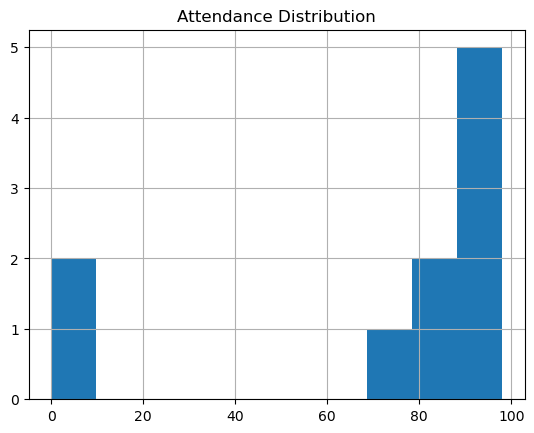

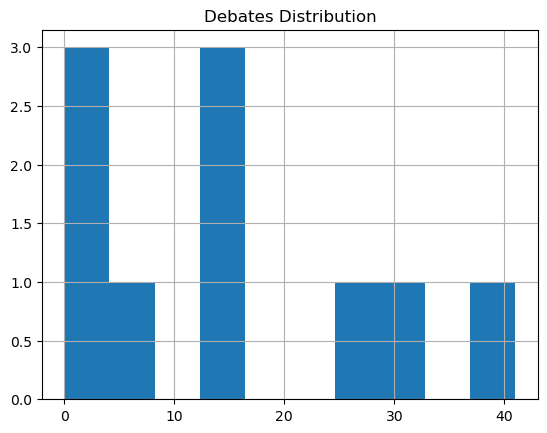

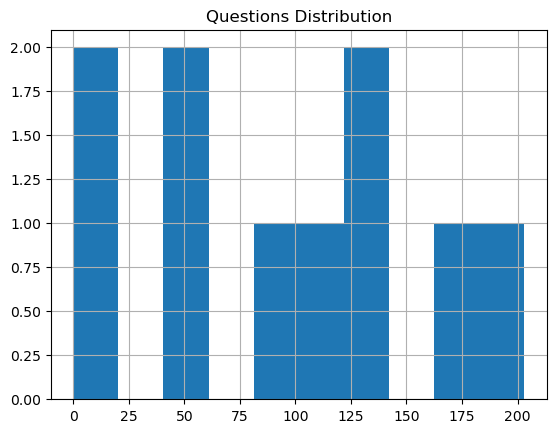

In [3]:
import matplotlib.pyplot as plt

df["attendance"].hist()
plt.title("Attendance Distribution")
plt.show()

df["debates"].hist()
plt.title("Debates Distribution")
plt.show()

df["questions"].hist()
plt.title("Questions Distribution")
plt.show()

In [4]:
# Min-Max Normalization

df["attendance_norm"] = (df["attendance"] - df["attendance"].min()) / (df["attendance"].max() - df["attendance"].min())

df["debates_norm"] = (df["debates"] - df["debates"].min()) / (df["debates"].max() - df["debates"].min())

df["questions_norm"] = (df["questions"] - df["questions"].min()) / (df["questions"].max() - df["questions"].min())

df.head()

,name,attendance,debates,questions,attendance_norm,debates_norm,questions_norm
0,Gaurav Gogoi,85,29,117,0.867347,0.707317,0.576355
1,Jai Parkash,97,5,43,0.989796,0.121951,0.211823
2,Sarbananda Sonowal,0,0,0,0.000000,0.000000,0.000000
3,Bibhu Prasad Tarai,93,14,141,0.948980,0.341463,0.694581
4,Shobhanaben Mahendrasinh Baraiya,98,15,173,1.000000,0.365854,0.852217


In [5]:
df["LCI_score"] = (
    df["attendance_norm"] * 0.4 +
    df["debates_norm"] * 0.3 +
    df["questions_norm"] * 0.3
)

df["LCI_score"] = (df["LCI_score"] * 100).round(2)

df.sort_values("LCI_score", ascending=False)

,name,attendance,debates,questions,attendance_norm,debates_norm,questions_norm,LCI_score
9,D M Kathir Anand,86,41,125,0.877551,1.000000,0.615764,83.57
7,Shrikant Eknath Shinde,78,27,203,0.795918,0.658537,1.000000,81.59
4,Shobhanaben Mahendrasinh Baraiya,98,15,173,1.000000,0.365854,0.852217,76.54
0,Gaurav Gogoi,85,29,117,0.867347,0.707317,0.576355,73.20
3,Bibhu Prasad Tarai,93,14,141,0.948980,0.341463,0.694581,69.04
6,Haribhai Patel,97,13,99,0.989796,0.317073,0.487685,63.73
1,Jai Parkash,97,5,43,0.989796,0.121951,0.211823,49.61
5,Amarsing Tisso,96,1,54,0.979592,0.024390,0.266010,47.90
2,Sarbananda Sonowal,0,0,0,0.000000,0.000000,0.000000,0.00
8,Ajay Tamta,0,0,0,0.000000,0.000000,0.000000,0.00


In [6]:
df["rank"] = df["LCI_score"].rank(ascending=False, method="min")

df = df.sort_values("LCI_score", ascending=False)

df.head()

,name,attendance,debates,questions,attendance_norm,debates_norm,questions_norm,LCI_score,rank
9,D M Kathir Anand,86,41,125,0.877551,1.000000,0.615764,83.57,1.0
7,Shrikant Eknath Shinde,78,27,203,0.795918,0.658537,1.000000,81.59,2.0
4,Shobhanaben Mahendrasinh Baraiya,98,15,173,1.000000,0.365854,0.852217,76.54,3.0
0,Gaurav Gogoi,85,29,117,0.867347,0.707317,0.576355,73.20,4.0
3,Bibhu Prasad Tarai,93,14,141,0.948980,0.341463,0.694581,69.04,5.0


In [7]:
print("🏆 Top 5 Performing MPs")
display(df[["name", "attendance", "debates", "questions", "LCI_score", "rank"]].head(5))

print("\n⚠️ Bottom 5 Performing MPs")
display(df[["name", "attendance", "debates", "questions", "LCI_score", "rank"]].tail(5))

🏆 Top 5 Performing MPs


,name,attendance,debates,questions,LCI_score,rank
9,D M Kathir Anand,86,41,125,83.57,1.0
7,Shrikant Eknath Shinde,78,27,203,81.59,2.0
4,Shobhanaben Mahendrasinh Baraiya,98,15,173,76.54,3.0
0,Gaurav Gogoi,85,29,117,73.20,4.0
3,Bibhu Prasad Tarai,93,14,141,69.04,5.0



⚠️ Bottom 5 Performing MPs


,name,attendance,debates,questions,LCI_score,rank
6,Haribhai Patel,97,13,99,63.73,6.0
1,Jai Parkash,97,5,43,49.61,7.0
5,Amarsing Tisso,96,1,54,47.90,8.0
2,Sarbananda Sonowal,0,0,0,0.00,9.0
8,Ajay Tamta,0,0,0,0.00,9.0


In [8]:
df.to_csv("mp_scored.csv", index=False)

print("✅ mp_scored.csv saved successfully.")

✅ mp_scored.csv saved successfully.
